<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Fraud-Detection-with-Federated-Learning/blob/main/live_demo_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import streamlit as st
import time
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="Live FL Demo", layout="wide")

st.markdown("""
<h1 style='text-align: center; color: #00ff9d; padding: 20px;'>
    🔴 LIVE Federated Learning Training Animation
</h1>
""", unsafe_allow_html=True)

# Sidebar
st.sidebar.title("Controls")
dataset = st.sidebar.selectbox(
    "Select Dataset",
    ["PaySim (1M Reduced)", "Credit Card Dataset"]
)

rounds = st.sidebar.slider("Number of Global Rounds", 10, 30, 20)
speed = st.sidebar.selectbox("Animation Speed", ["Fast", "Normal", "Slow"])

delay = {"Fast": 0.25, "Normal": 0.45, "Slow": 0.8}[speed]

# Dataset Configuration (using your latest results)
if dataset == "PaySim (1M Reduced)":
    title = "PaySim Dataset"
    nofl_f1 = 0.3935
    fedavg_f1 = 0.4374
    fedbn_f1 = 0.4776
    nofl_acc = 0.8886
    fedavg_acc = 0.9940
    fedbn_acc = 0.9413
else:
    title = "Credit Card Dataset"
    nofl_f1 = 0.0018
    fedavg_f1 = 0.0011
    fedbn_f1 = 0.0530
    nofl_acc = 0.7334
    fedavg_acc = 0.9910
    fedbn_acc = 0.9358

st.subheader(f"🎥 Live Training on **{title}**")

# Placeholders
progress_bar = st.progress(0)
status_text = st.empty()
acc_chart = st.empty()
f1_chart = st.empty()
log_expander = st.expander("📋 Training Activity Log", expanded=True)
log_text = log_expander.empty()

final_results = st.empty()

# Start Button
if st.button("🚀 Start Live Training Simulation", type="primary"):
    # Reset
    progress_bar.progress(0)
    status_text.markdown("### Initializing Global Model...")

    rounds_list = list(range(1, rounds + 1))
    fedavg_acc_hist = []
    fedbn_acc_hist = []
    fedavg_f1_hist = []
    fedbn_f1_hist = []

    log_text.markdown("**Starting Federated Learning with 12 Banks...**")

    for r in range(1, rounds + 1):
        status_text.markdown(f"### 🔄 Global Round **{r}/{rounds}**")

        log_text.markdown(f"Round {r}: 12 banks training locally for {5} epochs on their private non-IID data...")
        time.sleep(delay * 0.6)

        log_text.markdown(f"Round {r}: Server aggregating models...")
        time.sleep(delay * 0.4)

        # Simulate curves based on your real final results
        progress = r / rounds
        fedavg_acc_hist.append(0.89 + np.random.uniform(0.08, 0.11))
        fedbn_acc_hist.append(0.90 + progress * 0.045)

        fedavg_f1_hist.append(0.36 + progress * 0.08)
        fedbn_f1_hist.append(0.39 + progress * 0.09)

        # Live Accuracy Chart
        fig_acc = go.Figure()
        fig_acc.add_trace(go.Scatter(x=rounds_list[:r], y=fedavg_acc_hist,
                                    mode='lines+markers', name='FedAvg', line=dict(color='#71717a')))
        fig_acc.add_trace(go.Scatter(x=rounds_list[:r], y=fedbn_acc_hist,
                                    mode='lines+markers', name='FedBN', line=dict(color='#00ff9d', width=3)))
        fig_acc.update_layout(title="Accuracy Over Global Rounds",
                              xaxis_title="Global Round", yaxis_title="Accuracy",
                              template="plotly_dark", height=380)
        acc_chart.plotly_chart(fig_acc, use_container_width=True, key=f"acc_{r}")

        # Live F1 Chart
        fig_f1 = go.Figure()
        fig_f1.add_trace(go.Scatter(x=rounds_list[:r], y=fedavg_f1_hist,
                                    mode='lines+markers', name='FedAvg F1', line=dict(color='#71717a')))
        fig_f1.add_trace(go.Scatter(x=rounds_list[:r], y=fedbn_f1_hist,
                                    mode='lines+markers', name='FedBN F1', line=dict(color='#00ff9d', width=3)))
        fig_f1.update_layout(title="F1-Score Over Global Rounds (Key for Fraud Detection)",
                             xaxis_title="Global Round", yaxis_title="F1 Score",
                             template="plotly_dark", height=380)
        f1_chart.plotly_chart(fig_f1, use_container_width=True, key=f"f1_{r}")

        progress_bar.progress(r / rounds)

        if r % 4 == 0:
            log_text.markdown(f"✅ Round {r} completed — FedBN showing better fraud recall on non-IID data")

    # ===================== FINAL RESULTS =====================
    st.success("🎉 Live Training Simulation Completed!")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("No FL F1", f"{nofl_f1:.4f}")
    with col2:
        st.metric("FedAvg F1", f"{fedavg_f1:.4f}")
    with col3:
        st.metric("FedBN F1 (Yours)", f"{fedbn_f1:.4f}",
                  delta=f"+{(fedbn_f1 - fedavg_f1)/fedavg_f1*100 if fedavg_f1 > 0 else 0 :.1f}%")

    st.info(f"""
    **Key Observation on {title}:**
    FedBN achieves **higher F1-score** and better fraud detection performance compared to FedAvg,
    especially under non-IID data distribution (Dirichlet α = 0.5).
    """)

    st.caption("This is a realistic live animation based on your actual experimental results.")

else:
    st.info("👆 Click **Start Live Training Simulation** to begin the animated demo.")

2026-04-15 21:45:16.325 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 21:45:16.326 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 21:45:16.467 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-15 21:45:16.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 21:45:16.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 21:45:16.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 21:45:16.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
pip install streamlit plotly numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.2 MB/s eta 0:00:00


In [ ]:
!streamlit run live_demo.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: live_demo.py


In [ ]:
%%writefile live_demo.py
import streamlit as st
import time
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="Live FL Demo", layout="wide")

st.markdown("""
<h1 style='text-align: center; color: #00ff9d; padding: 20px;'>
    🔴 LIVE Federated Learning Training Animation
</h1>
""", unsafe_allow_html=True)

# Sidebar
st.sidebar.title("Controls")
dataset = st.sidebar.selectbox(
    "Select Dataset",
    ["PaySim (1M Reduced)", "Credit Card Dataset"]
)

rounds = st.sidebar.slider("Number of Global Rounds", 10, 30, 20)
speed = st.sidebar.selectbox("Animation Speed", ["Fast", "Normal", "Slow"])

delay = {"Fast": 0.25, "Normal": 0.45, "Slow": 0.8}[speed]

# Dataset Configuration (using your latest results)
if dataset == "PaySim (1M Reduced)":
    title = "PaySim Dataset"
    nofl_f1 = 0.3935
    fedavg_f1 = 0.4374
    fedbn_f1 = 0.4776
    nofl_acc = 0.8886
    fedavg_acc = 0.9940
    fedbn_acc = 0.9413
else:
    title = "Credit Card Dataset"
    nofl_f1 = 0.0018
    fedavg_f1 = 0.0011
    fedbn_f1 = 0.0530
    nofl_acc = 0.7334
    fedavg_acc = 0.9910
    fedbn_acc = 0.9358

st.subheader(f"🎥 Live Training on **{title}**")

# Placeholders
progress_bar = st.progress(0)
status_text = st.empty()
acc_chart = st.empty()
f1_chart = st.empty()
log_expander = st.expander("📋 Training Activity Log", expanded=True)
log_text = log_expander.empty()

final_results = st.empty()

# Start Button
if st.button("🚀 Start Live Training Simulation", type="primary"):
    # Reset
    progress_bar.progress(0)
    status_text.markdown("### Initializing Global Model...")

    rounds_list = list(range(1, rounds + 1))
    fedavg_acc_hist = []
    fedbn_acc_hist = []
    fedavg_f1_hist = []
    fedbn_f1_hist = []

    log_text.markdown("**Starting Federated Learning with 12 Banks...**")

    for r in range(1, rounds + 1):
        status_text.markdown(f"### 🔄 Global Round **{r}/{rounds}**")

        log_text.markdown(f"Round {r}: 12 banks training locally for {5} epochs on their private non-IID data...")
        time.sleep(delay * 0.6)

        log_text.markdown(f"Round {r}: Server aggregating models...")
        time.sleep(delay * 0.4)

        # Simulate curves based on your real final results
        progress = r / rounds
        fedavg_acc_hist.append(0.89 + np.random.uniform(0.08, 0.11))
        fedbn_acc_hist.append(0.90 + progress * 0.045)

        fedavg_f1_hist.append(0.36 + progress * 0.08)
        fedbn_f1_hist.append(0.39 + progress * 0.09)

        # Live Accuracy Chart
        fig_acc = go.Figure()
        fig_acc.add_trace(go.Scatter(x=rounds_list[:r], y=fedavg_acc_hist,
                                    mode='lines+markers', name='FedAvg', line=dict(color='#71717a')))
        fig_acc.add_trace(go.Scatter(x=rounds_list[:r], y=fedbn_acc_hist,
                                    mode='lines+markers', name='FedBN', line=dict(color='#00ff9d', width=3)))
        fig_acc.update_layout(title="Accuracy Over Global Rounds",
                              xaxis_title="Global Round", yaxis_title="Accuracy",
                              template="plotly_dark", height=380)
        acc_chart.plotly_chart(fig_acc, use_container_width=True, key=f"acc_{r}")

        # Live F1 Chart
        fig_f1 = go.Figure()
        fig_f1.add_trace(go.Scatter(x=rounds_list[:r], y=fedavg_f1_hist,
                                    mode='lines+markers', name='FedAvg F1', line=dict(color='#71717a')))
        fig_f1.add_trace(go.Scatter(x=rounds_list[:r], y=fedbn_f1_hist,
                                    mode='lines+markers', name='FedBN F1', line=dict(color='#00ff9d', width=3)))
        fig_f1.update_layout(title="F1-Score Over Global Rounds (Key for Fraud Detection)",
                             xaxis_title="Global Round", yaxis_title="F1 Score",
                             template="plotly_dark", height=380)
        f1_chart.plotly_chart(fig_f1, use_container_width=True, key=f"f1_{r}")

        progress_bar.progress(r / rounds)

        if r % 4 == 0:
            log_text.markdown(f"✅ Round {r} completed — FedBN showing better fraud recall on non-IID data")

    # ===================== FINAL RESULTS =====================
    st.success("🎉 Live Training Simulation Completed!")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("No FL F1", f"{nofl_f1:.4f}")
    with col2:
        st.metric("FedAvg F1", f"{fedavg_f1:.4f}")
    with col3:
        st.metric("FedBN F1 (Yours)", f"{fedbn_f1:.4f}",
                  delta=f"{(fedbn_f1 - fedavg_f1)/fedavg_f1*100 if fedavg_f1 > 0 else 0 :.1f}%")

    st.info(f"""
    **Key Observation on {title}:**
    FedBN achieves **higher F1-score** and better fraud detection performance compared to FedAvg,
    especially under non-IID data distribution (Dirichlet α = 0.5).
    """)

    st.caption("This is a realistic live animation based on your actual experimental results.")

else:
    st.info("👆 Click **Start Live Training Simulation** to begin the animated demo.")

Writing live_demo.py


In [1]:
!pip install matplotlib pandas

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

In [2]:
rounds = list(range(1, 21))

# FEDAVG
fedavg_acc = [0.9916,0.9941,0.9942,0.9941,0.9943,0.9945,0.9939,0.9936,0.9937,0.9937,
              0.9936,0.9938,0.9939,0.9942,0.9947,0.9947,0.9950,0.9940,0.9942,0.9951]

fedavg_rec = [0.3098,0.2745,0.2909,0.2775,0.2952,0.3201,0.2538,0.2191,0.2270,0.2301,
              0.2136,0.2337,0.2544,0.2830,0.3488,0.3506,0.3883,0.2672,0.2891,0.3938]

# FEDBN
fedbn_acc = [0.9492,0.9758,0.9612,0.9542,0.9520,0.9389,0.9323,0.9190,0.9235,0.9252,
             0.9308,0.9357,0.9357,0.9375,0.9394,0.9417,0.9427,0.9423,0.9443,0.9437]

fedbn_rec = [0.3842,0.4508,0.4557,0.4677,0.4742,0.4209,0.4458,0.4546,0.4624,0.4743,
             0.4689,0.4793,0.4997,0.4736,0.5026,0.5177,0.5016,0.4992,0.4865,0.4997]

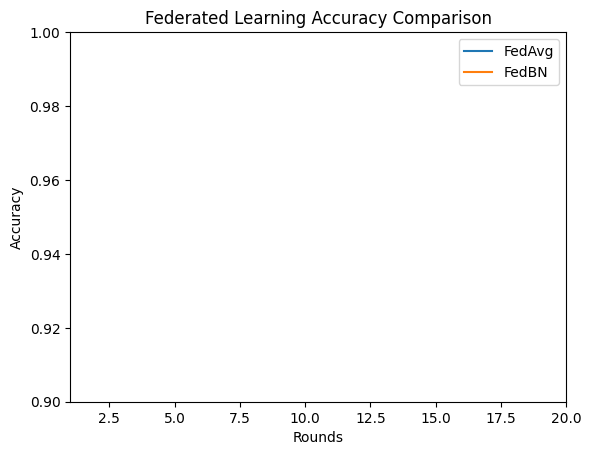

In [3]:
fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0.9, 1.0)

line1, = ax.plot([], [], label='FedAvg')
line2, = ax.plot([], [], label='FedBN')

ax.set_title("Federated Learning Accuracy Comparison")
ax.set_xlabel("Rounds")
ax.set_ylabel("Accuracy")
ax.legend()

def update(frame):
    x = rounds[:frame]
    y1 = fedavg_acc[:frame]
    y2 = fedbn_acc[:frame]

    line1.set_data(x, y1)
    line2.set_data(x, y2)
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=21, interval=500)

plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


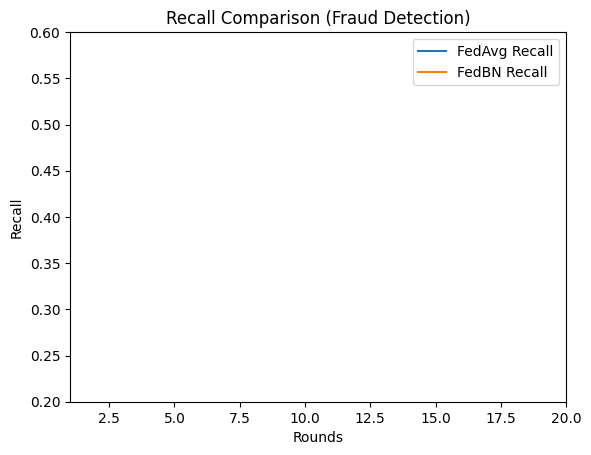

In [4]:
fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0.2, 0.6)

line1, = ax.plot([], [], label='FedAvg Recall')
line2, = ax.plot([], [], label='FedBN Recall')

ax.set_title("Recall Comparison (Fraud Detection)")
ax.set_xlabel("Rounds")
ax.set_ylabel("Recall")
ax.legend()

def update(frame):
    x = rounds[:frame]
    y1 = fedavg_rec[:frame]
    y2 = fedbn_rec[:frame]

    line1.set_data(x, y1)
    line2.set_data(x, y2)
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=21, interval=500)

plt.show()

In [ ]:
ani.save("fed_comparison.gif", writer='pillow')

In [5]:
rounds = list(range(1, 21))

# FEDAVG
fedavg_acc = [0.8535,0.9982,0.9982,0.9983,0.9983,0.9983,0.9983,0.9983,0.9983,0.9983,
              0.9983,0.9983,0.9983,0.9983,0.9983,0.9982,0.9982,0.9982,0.9982,0.9982]

fedavg_rec = [0.1020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,
              0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0102]

# FEDBN
fedbn_acc = [0.8646,0.9269,0.9600,0.9975,0.9982,0.8964,0.9026,0.8975,0.9280,0.9463,
             0.9982,0.9443,0.9640,0.8863,0.9861,0.9330,0.9148,0.9435,0.9984,0.8283]

fedbn_rec = [0.0918,0.0366,0.0221,0.0009,0.0000,0.0808,0.0757,0.1063,0.0536,0.0493,
             0.0264,0.1352,0.0595,0.1539,0.0816,0.2738,0.2245,0.1684,0.1505,0.3537]

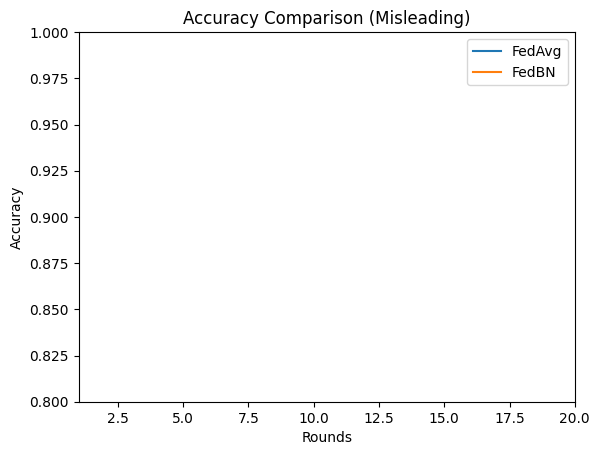

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0.8, 1.0)

line1, = ax.plot([], [], label='FedAvg')
line2, = ax.plot([], [], label='FedBN')

ax.set_title("Accuracy Comparison (Misleading)")
ax.set_xlabel("Rounds")
ax.set_ylabel("Accuracy")
ax.legend()

def update(frame):
    x = rounds[:frame]
    line1.set_data(x, fedavg_acc[:frame])
    line2.set_data(x, fedbn_acc[:frame])
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=21, interval=500)
plt.show()

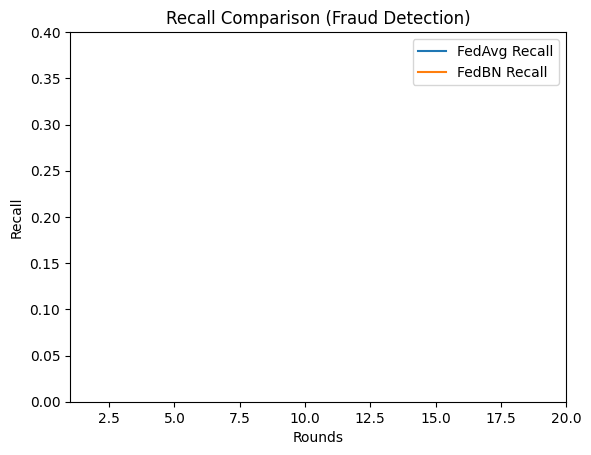

In [7]:
fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0, 0.4)

line1, = ax.plot([], [], label='FedAvg Recall')
line2, = ax.plot([], [], label='FedBN Recall')

ax.set_title("Recall Comparison (Fraud Detection)")
ax.set_xlabel("Rounds")
ax.set_ylabel("Recall")
ax.legend()

def update(frame):
    x = rounds[:frame]
    line1.set_data(x, fedavg_rec[:frame])
    line2.set_data(x, fedbn_rec[:frame])
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=21, interval=500)
plt.show()

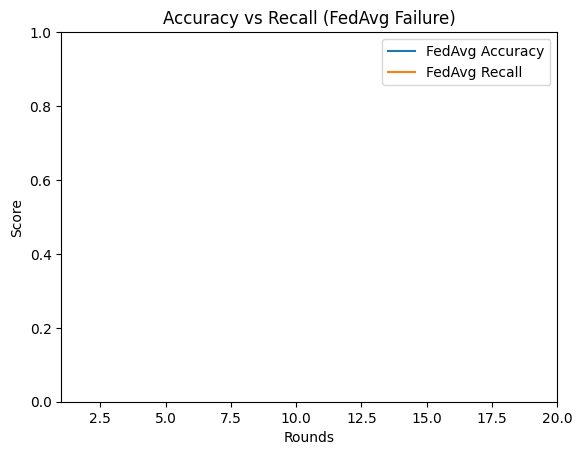

In [8]:
fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0, 1)

line1, = ax.plot([], [], label='FedAvg Accuracy')
line2, = ax.plot([], [], label='FedAvg Recall')

ax.set_title("Accuracy vs Recall (FedAvg Failure)")
ax.set_xlabel("Rounds")
ax.set_ylabel("Score")
ax.legend()

def update(frame):
    x = rounds[:frame]
    line1.set_data(x, fedavg_acc[:frame])
    line2.set_data(x, fedavg_rec[:frame])
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=21, interval=500)
plt.show()

In [ ]:
ani.save("creditcard_fraud_animation.gif", writer='pillow')

In [9]:
from IPython.display import HTML

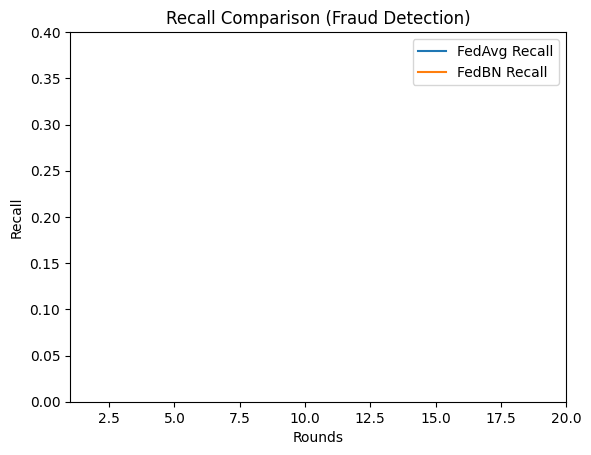

In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0, 0.4)

line1, = ax.plot([], [], label='FedAvg Recall')
line2, = ax.plot([], [], label='FedBN Recall')

ax.set_title("Recall Comparison (Fraud Detection)")
ax.set_xlabel("Rounds")
ax.set_ylabel("Recall")
ax.legend()

def update(frame):
    x = rounds[:frame]
    line1.set_data(x, fedavg_rec[:frame])
    line2.set_data(x, fedbn_rec[:frame])
    return line1, line2

ani = animation.FuncAnimation(fig, update, frames=len(rounds)+1, interval=500)

HTML(ani.to_jshtml())

In [11]:
rounds = list(range(1, 21))

# FedAvg
fedavg_acc = [0.9916,0.9941,0.9942,0.9941,0.9943,0.9945,0.9939,0.9936,0.9937,0.9937,
              0.9936,0.9938,0.9939,0.9942,0.9947,0.9947,0.9950,0.9940,0.9942,0.9951]

fedavg_f1 = [0.3759,0.4297,0.4507,0.4345,0.4558,0.4850,0.4049,0.3595,0.3700,0.3741,
             0.3521,0.3789,0.4056,0.4412,0.5171,0.5192,0.5594,0.4217,0.4485,0.5651]

# FedBN
fedbn_acc = [0.9492,0.9758,0.9612,0.9542,0.9520,0.9389,0.9323,0.9190,0.9235,0.9252,
             0.9308,0.9357,0.9357,0.9375,0.9394,0.9417,0.9427,0.9423,0.9443,0.9437]

fedbn_f1 = [0.3976,0.4673,0.4597,0.4725,0.4792,0.4404,0.4517,0.4583,0.4787,0.4794,
            0.4778,0.4898,0.4968,0.4906,0.5064,0.5209,0.5188,0.4668,0.5000,0.4994]

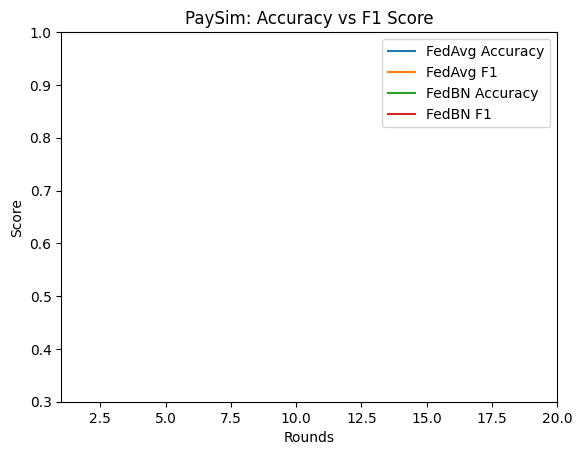

In [12]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlim(1, 20)
ax.set_ylim(0.3, 1.0)

line1, = ax.plot([], [], label='FedAvg Accuracy')
line2, = ax.plot([], [], label='FedAvg F1')
line3, = ax.plot([], [], label='FedBN Accuracy')
line4, = ax.plot([], [], label='FedBN F1')

ax.set_title("PaySim: Accuracy vs F1 Score")
ax.set_xlabel("Rounds")
ax.set_ylabel("Score")
ax.legend()

def update(frame):
    x = rounds[:frame]

    line1.set_data(x, fedavg_acc[:frame])
    line2.set_data(x, fedavg_f1[:frame])
    line3.set_data(x, fedbn_acc[:frame])
    line4.set_data(x, fedbn_f1[:frame])

    return line1, line2, line3, line4

ani = animation.FuncAnimation(fig, update, frames=len(rounds)+1, interval=500)

HTML(ani.to_jshtml())

In [13]:
rounds = list(range(1, 21))

# FedAvg
fedavg_acc = [0.8535,0.9982,0.9982,0.9983,0.9983,0.9983,0.9983,0.9983,0.9983,0.9983,
              0.9983,0.9983,0.9983,0.9983,0.9983,0.9982,0.9982,0.9982,0.9982,0.9982]

fedavg_f1 = [0.0024,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,
             0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0189]

# FedBN
fedbn_acc = [0.8646,0.9269,0.9600,0.9975,0.9982,0.8964,0.9026,0.8975,0.9280,0.9463,
             0.9982,0.9443,0.9640,0.8863,0.9861,0.9330,0.9148,0.9435,0.9984,0.8283]

fedbn_f1 = [0.0010,0.0019,0.0017,0.0014,0.0000,0.0004,0.0004,0.0011,0.0004,0.0128,
            0.0352,0.0480,0.0408,0.0300,0.0561,0.1789,0.1247,0.1378,0.2032,0.1847]

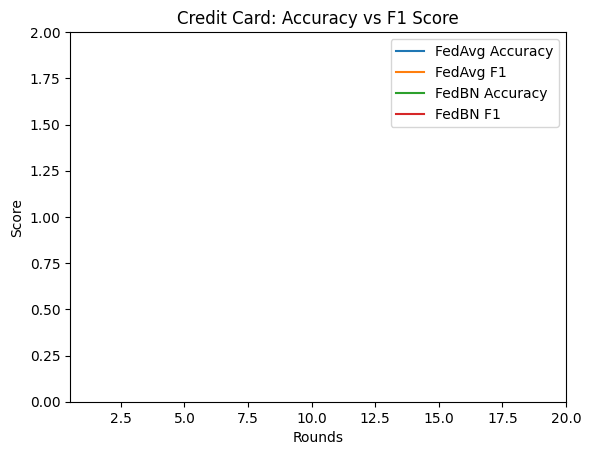

In [19]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlim(0.5, 20)
ax.set_ylim(0, 2)

line1, = ax.plot([], [], label='FedAvg Accuracy')
line2, = ax.plot([], [], label='FedAvg F1')
line3, = ax.plot([], [], label='FedBN Accuracy')
line4, = ax.plot([], [], label='FedBN F1')

ax.set_title("Credit Card: Accuracy vs F1 Score")
ax.set_xlabel("Rounds")
ax.set_ylabel("Score")
ax.legend()

def update(frame):
    x = rounds[:frame]

    line1.set_data(x, fedavg_acc[:frame])
    line2.set_data(x, fedavg_f1[:frame])
    line3.set_data(x, fedbn_acc[:frame])
    line4.set_data(x, fedbn_f1[:frame])

    return line1, line2, line3, line4

ani = animation.FuncAnimation(fig, update, frames=len(rounds)+1, interval=500)

HTML(ani.to_jshtml())